# Data-Driven UX: User Funnel and A/A/B Test for Food Startups
### Conversion analysis and experiment-based decision making.

## Introducción

En el entorno competitivo de las empresas emergentes, comprender el comportamiento del usuario es fundamental para optimizar la experiencia digital y maximizar las conversiones. Este proyecto aborda un análisis integral del embudo de ventas y la evaluación de un experimento A/A/B en la aplicación de una empresa de productos alimenticios. El objetivo es identificar cuellos de botella en el recorrido del usuario y determinar si un cambio propuesto en las fuentes tipográficas de la aplicación afecta significativamente el comportamiento de los usuarios. Para ello, se analiza un conjunto de datos de eventos de usuario, que incluye registros de interacciones clave como la visualización de pantallas principales, ofertas, carrito de compras y pagos exitosos, distribuidos en grupos de control y prueba.

## Objetivo General:

El objetivo general de este proyecto es realizar un análisis de datos que permita, por un lado, evaluar el desempeño del embudo de conversión de la aplicación para identificar etapas críticas donde se pierden usuarios y, por otro, determinar mediante un test A/A/B si la implementación de un nuevo conjunto de fuentes tipográficas influye de manera estadísticamente significativa en las tasas de interacción y conversión de los usuarios. Esto proporcionará a la empresa insights basados en datos para tomar decisiones informadas sobre la optimización de la interfaz y la experiencia del usuario.

In [1]:
#Importar librerías y datos a analizar.
import pandas as pd
import scipy.stats as st
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from statsmodels.stats.proportion import proportions_ztest

data = pd.read_csv('logs_exp_us.csv', sep = '\t')
data.columns = ['event', 'user_id', 'datetime', 'group']
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   event     244126 non-null  object
 1   user_id   244126 non-null  int64 
 2   datetime  244126 non-null  int64 
 3   group     244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


No hay valores ausentes.

In [2]:
data.duplicated().sum()

np.int64(413)

In [3]:
#Se eliminan las filas duplicadas
data = data.drop_duplicates().reset_index(drop=True)
len(data)

243713

In [4]:
#Se modifican los tipos de datos
data['datetime'] = pd.to_datetime(data['datetime'], unit='s')
data['date'] = data['datetime'].dt.date
data['date'] = pd.to_datetime(data['date'])
data['year'] = data['datetime'].dt.year
data['month'] = data['datetime'].dt.month
data['day'] = data['datetime'].dt.day
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243713 entries, 0 to 243712
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   event     243713 non-null  object        
 1   user_id   243713 non-null  int64         
 2   datetime  243713 non-null  datetime64[ns]
 3   group     243713 non-null  int64         
 4   date      243713 non-null  datetime64[ns]
 5   year      243713 non-null  int32         
 6   month     243713 non-null  int32         
 7   day       243713 non-null  int32         
dtypes: datetime64[ns](2), int32(3), int64(2), object(1)
memory usage: 12.1+ MB


In [5]:
data.head()

,event,user_id,datetime,group,date,year,month,day
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25,2019,7,25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25,2019,7,25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25,2019,7,25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25,2019,7,25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25,2019,7,25


In [6]:
#¿Cuántos eventos hay en los registros?
print(data['event'].unique())
print('')
print('Eventos únicos: ', data['event'].nunique())
print('Eventos totales: ', len(data['event']))

['MainScreenAppear' 'PaymentScreenSuccessful' 'CartScreenAppear'
 'OffersScreenAppear' 'Tutorial']

Eventos únicos:  5
Eventos totales:  243713


In [7]:
#¿Cuántos usuarios hay en los registros?
print(data['user_id'].nunique())

7551


In [8]:
#¿Cuál es el promedio de eventos por usuario?
print(data.groupby('user_id')['event'].count().mean())

32.27559263673685


In [9]:
#¿Qué periodo de tiempo cubren los datos? 
print(data['datetime'].min())
print(data['datetime'].max())
print(data['datetime'].max() - data['datetime'].min())

2019-07-25 04:43:36
2019-08-07 21:15:17
13 days 16:31:41


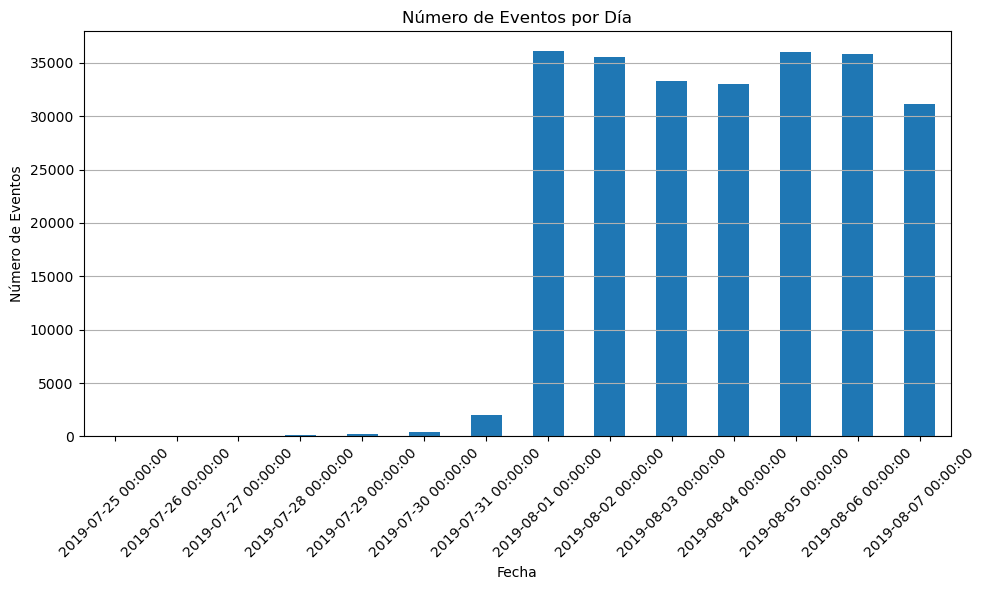

In [10]:
#Traza un histograma por fecha y hora.
eventos_por_dia = data['date'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
eventos_por_dia.plot(kind='bar')
plt.title('Número de Eventos por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Como se puede ver en el diagrama, se recolectaron muchos más datos desde el 2019-08-01. Es muy probable que se tuvieran problemas en la recolección de datos anterior a esta fecha, por lo tanto se omitirán estos resultados.

In [11]:
#Se toman únicamente los datos desde el 2019-08-01
data_filtrada = data[data['date'] >= '2019-08-01']

#¿Qué periodo representan realmente los datos?
print(data_filtrada['datetime'].min())
print(data_filtrada['datetime'].max())
print(data_filtrada['datetime'].max() - data_filtrada['datetime'].min())

2019-08-01 00:07:28
2019-08-07 21:15:17
6 days 21:07:49


In [12]:
len(data_filtrada)

240887

In [13]:
#Se tienen usuarios repetidos entre grupos?
grupo_246 = data_filtrada[data_filtrada['group'] == '246']['user_id'].unique()
grupo_247 = data_filtrada[data_filtrada['group'] == '247']['user_id'].unique()
grupo_248 = data_filtrada[data_filtrada['group'] == '248']['user_id'].unique()
grupo_246 = pd.Series(grupo_246)
grupo_247 = pd.Series(grupo_247)
grupo_248 = pd.Series(grupo_248)

repetidos_1 = grupo_246[(grupo_246.isin(grupo_247) | grupo_246.isin(grupo_248))]
repetidos_2 = grupo_247[grupo_247.isin(grupo_248)]
repetidos = pd.concat([repetidos_1, repetidos_2]).unique()

data_filtrada = data_filtrada[~data_filtrada['user_id'].isin(repetidos)]
len(data_filtrada)

240887

No hay usuarios repetidos entre los grupos.

In [14]:
#¿Perdiste muchos eventos y usuarios al excluir los datos más antiguos?
print('Usuarios únicos: ', data_filtrada['user_id'].nunique())
print('Eventos totales: ', len(data_filtrada['event']))
print('')
print('Usuarios excluidos: ', data['user_id'].nunique() - data_filtrada['user_id'].nunique(), 
     ' , Porcentaje total: ', round((data['user_id'].nunique() - data_filtrada['user_id'].nunique())/(data_filtrada['user_id'].nunique())*100, 2), '%')
print('Eventos excluidos: ', len(data['event']) - len(data_filtrada['event']),
     ' , Porcentaje total: ', round((len(data['event']) - len(data_filtrada['event']))/(len(data_filtrada['event']))*100, 2), '%')

Usuarios únicos:  7534
Eventos totales:  240887

Usuarios excluidos:  17  , Porcentaje total:  0.23 %
Eventos excluidos:  2826  , Porcentaje total:  1.17 %


El porcentaje de usuarios y eventos excluidos es muy pequeño, por lo que se mantiene la decisión de ajustar las fechas analizadas.

In [15]:
#Asegúrate de tener usuarios de los tres grupos experimentales.
usuarios246 = data_filtrada[data_filtrada['group'] == 246]
usuarios247 = data_filtrada[data_filtrada['group'] == 247]
usuarios248 = data_filtrada[data_filtrada['group'] == 248]
print(usuarios246['user_id'].nunique() > 0)
print(usuarios247['user_id'].nunique() > 0)
print(usuarios248['user_id'].nunique() > 0)

True
True
True


Si hay usuarios en los tres grupos experimentales.

In [16]:
#Observa qué eventos hay en los registros y su frecuencia de suceso. Ordénalos por frecuencia.
data_filtrada['event'].value_counts()

event
MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: count, dtype: int64

In [17]:
#Encuentra la cantidad de usuarios que realizaron cada una de estas acciones.
eventos_por_usuario = data_filtrada.groupby('event')['user_id'].nunique().sort_values(ascending=False)
print(eventos_por_usuario)
print('')

#Calcula la proporción de usuarios que realizaron la acción al menos una vez.
total_usuarios = data_filtrada['user_id'].nunique()
proporcion_eventos = (eventos_por_usuario / total_usuarios * 100).round(2)
print(proporcion_eventos)

event
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: user_id, dtype: int64

event
MainScreenAppear           98.47
OffersScreenAppear         60.96
CartScreenAppear           49.56
PaymentScreenSuccessful    46.97
Tutorial                   11.15
Name: user_id, dtype: float64


La proporción de usuarios por cada evento muestra el orden en el que se generan dichos eventos. Sin embargo, no se especifica la naturaleza del Tutorial, por lo tanto se supone que lo utilizan principalmente usuarios nuevos que no están familiarizados con la página y posteriormente lo dejan de utilizar. Por este motivo, no se considera necesario incluir el tutorial en el análisis de embudo. Ahora bien, el comportamiento de los usuarios puede variar, por ejemplo, no necesariamente tienen que ver una oferta para agregar un producto en el carrito; así mismo, no todos empiezan el proceso desde la pestaña principal de la página, posiblemente entren directamente por anuncios de las ofertas de un producto. 

El orden del embudo según la proporción de usuarios por etapa sería la siguiente: MainScreenAppear > OffersScreenAppear > CartScreenAppear > PaymentScreenSuccessful.
Etapa_A > Etapa_B > Etapa_C > Etapa_D

In [18]:
#Utiliza el embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente.
eventos_por_usuario = eventos_por_usuario.reset_index()
eventos_por_usuario.columns = ['event', 'users']
eventos_por_usuario

,event,users
0,MainScreenAppear,7419
1,OffersScreenAppear,4593
2,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539
4,Tutorial,840


In [19]:
#Eliminamos el evento Tutorial del embudo y agregamos la columna proporcion
etapas_embudo = eventos_por_usuario[eventos_por_usuario['event'] != 'Tutorial'].copy()
etapas_embudo['proporcion'] = round((etapas_embudo['users'].shift(-1) / etapas_embudo['users']) * 100, 2)
etapas_embudo

,event,users,proporcion
0,MainScreenAppear,7419,61.91
1,OffersScreenAppear,4593,81.30
2,CartScreenAppear,3734,94.78
3,PaymentScreenSuccessful,3539,NaN


Se pierden más usuarios entre la página principal y la página de ofertas. Es más probale que los usuarios lleguen a la página de pago si ven las ofertas.

In [20]:
#Gráfico funnel del embudo
fig = px.funnel(etapas_embudo, x='users', y='event', title='Embudo de Conversión de Usuarios')
fig.update_layout(xaxis_title='Número de Usuarios', yaxis_title='Etapas')
fig.show()

In [21]:
#¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago?
usuarios_etapa_A = data_filtrada[data_filtrada['event'] == 'MainScreenAppear']['user_id'].nunique()
usuarios_etapa_D = data_filtrada[data_filtrada['event'] == 'PaymentScreenSuccessful']['user_id'].nunique()

porcentaje_embudo_completo = round((usuarios_etapa_D / usuarios_etapa_A) * 100, 2)
print('Procentaje de usuarios que hacen el viaje completo: ', porcentaje_embudo_completo)

Procentaje de usuarios que hacen el viaje completo:  47.7


In [22]:
#¿Cuántos usuarios hay en cada grupo?
usuarios_totales_246 = usuarios246['user_id'].nunique()
usuarios_totales_247 = usuarios247['user_id'].nunique()
usuarios_totales_248 = usuarios248['user_id'].nunique()

print('Usuarios en el grupo 246: ', usuarios_totales_246)
print('Usuarios en el grupo 247: ', usuarios_totales_247)
print('Usuarios en el grupo 248: ', usuarios_totales_248)

Usuarios en el grupo 246:  2484
Usuarios en el grupo 247:  2513
Usuarios en el grupo 248:  2537


In [23]:
#Observa si hay una diferencia estadísticamente significativa entre las muestras 246 y 247.
compradores_246 = usuarios246[usuarios246['event'] == 'PaymentScreenSuccessful']['user_id'].nunique()
compradores_247 = usuarios247[usuarios247['event'] == 'PaymentScreenSuccessful']['user_id'].nunique()

successes = [compradores_246, compradores_247]
nobs = [usuarios_totales_246, usuarios_totales_247]

stat, p_value = proportions_ztest(successes, nobs)
print(f'Z-Score: {stat}')
print(f'Valor p: {p_value}')
alpha = 0.05 

if p_value < alpha:
    print("Hay una diferencia estadísticamente significativa entre los grupos 246 y 247.")
else:
    print("No hay una diferencia estadísticamente significativa entre los grupos 246 y 247.")

Z-Score: 1.5779948491596598
Valor p: 0.11456679313141847
No hay una diferencia estadísticamente significativa entre los grupos 246 y 247.


Los dos grupos de control son similares, por lo que aumenta la confianza en la exactitud de los datos de la prueba.

In [24]:
#Selecciona el evento más popular.
evento_mas_popular = data_filtrada['event'].value_counts().idxmax()
evento_mas_popular

'MainScreenAppear'

In [25]:
#En cada uno de los grupos de control, encuentra la cantidad de usuarios que realizaron esta acción.
#Encuentra su proporción. Comprueba si la diferencia entre los grupos es estadísticamente significativa.

def analizar_evento(evento):
    usuarios_evento_246 = usuarios246[usuarios246['event'] == evento]['user_id'].unique()
    usuarios_evento_247 = usuarios247[usuarios247['event'] == evento]['user_id'].unique()
    total_usuarios_246 = len(usuarios_evento_246)
    total_usuarios_247 = len(usuarios_evento_247)

    global usuarios_totales_246
    global usuarios_totales_247
    proporcion_246 = round((total_usuarios_246 / usuarios_totales_246) * 100, 2)
    proporcion_247 = round((total_usuarios_247 / usuarios_totales_247) * 100, 2)

    successes = [total_usuarios_246, total_usuarios_247]
    nobs = [usuarios_totales_246, usuarios_totales_247]
    
    stat, p_value = proportions_ztest(successes, nobs)
    alpha = 0.05
    
    if p_value < alpha:
        respuesta = "Hay una diferencia estadísticamente significativa entre los grupos."
    else:
        respuesta = "No hay una diferencia estadísticamente significativa entre los grupos."
    
    return {
        'Evento': evento,
        'Usuarios_246': total_usuarios_246,
        'Proporcion_246': proporcion_246,
        'Usuarios_247': total_usuarios_247,
        'Proporcion_247': proporcion_247,
        'Estadistica': stat,
        'Valor_p': p_value,
        'Análisis': respuesta
    }

resultado_mas_popular = analizar_evento(evento_mas_popular)

print(f"\nEvento: {resultado_mas_popular['Evento']}")
print(f"Usuarios en grupo 246: {resultado_mas_popular['Usuarios_246']} ({resultado_mas_popular['Proporcion_246']}%)")
print(f"Usuarios en grupo 247: {resultado_mas_popular['Usuarios_247']} ({resultado_mas_popular['Proporcion_247']}%)")
print(f"Z-Score 246 vs 247: {resultado_mas_popular['Estadistica']}, Valor p: {resultado_mas_popular['Valor_p']}")
print(f"Resultado 246 vs 247: {resultado_mas_popular['Análisis']}")


Evento: MainScreenAppear
Usuarios en grupo 246: 2450 (98.63%)
Usuarios en grupo 247: 2476 (98.53%)
Z-Score 246 vs 247: 0.3093441851418436, Valor p: 0.7570597232046099
Resultado 246 vs 247: No hay una diferencia estadísticamente significativa entre los grupos.


In [26]:
#Repite el procedimiento para todos los demás eventos
eventos_unicos = data_filtrada['event'].unique()
resultados_eventos = []

for evento in eventos_unicos:
    if evento != evento_mas_popular:
        resultado = analizar_evento(evento)
        resultados_eventos.append(resultado)

for resultado in resultados_eventos:
    print(f"\nEvento: {resultado['Evento']}")
    print(f"Usuarios en grupo 246: {resultado['Usuarios_246']} ({resultado['Proporcion_246']}%)")
    print(f"Usuarios en grupo 247: {resultado['Usuarios_247']} ({resultado['Proporcion_247']}%)")
    print(f"Estadística U 246 vs 247: {resultado['Estadistica']}, Valor p: {resultado['Valor_p']}")
    print(f"Resultado 246 vs 247: {resultado['Análisis']}")


Evento: Tutorial
Usuarios en grupo 246: 278 (11.19%)
Usuarios en grupo 247: 283 (11.26%)
Estadística U 246 vs 247: -0.0781614596617372, Valor p: 0.9376996189257114
Resultado 246 vs 247: No hay una diferencia estadísticamente significativa entre los grupos.

Evento: OffersScreenAppear
Usuarios en grupo 246: 1542 (62.08%)
Usuarios en grupo 247: 1520 (60.49%)
Estadística U 246 vs 247: 1.154987713610383, Valor p: 0.2480954578522181
Resultado 246 vs 247: No hay una diferencia estadísticamente significativa entre los grupos.

Evento: CartScreenAppear
Usuarios en grupo 246: 1266 (50.97%)
Usuarios en grupo 247: 1238 (49.26%)
Estadística U 246 vs 247: 1.203368576486285, Valor p: 0.22883372237997213
Resultado 246 vs 247: No hay una diferencia estadísticamente significativa entre los grupos.

Evento: PaymentScreenSuccessful
Usuarios en grupo 246: 1200 (48.31%)
Usuarios en grupo 247: 1158 (46.08%)
Estadística U 246 vs 247: 1.5779948491596598, Valor p: 0.11456679313141847
Resultado 246 vs 247: No 

No se encontraron diferencias significativas entre los grupos de control asi que se confirma que estos se dividieron correctamente.

In [27]:
#Haz lo mismo para el grupo con fuentes alteradas. Compara los resultados con los de cada uno de los grupos de control para cada evento de forma aislada.
def analizar_grupos_por_evento(evento):
    usuarios_evento_246 = usuarios246[usuarios246['event'] == evento]['user_id'].unique()
    usuarios_evento_247 = usuarios247[usuarios247['event'] == evento]['user_id'].unique()
    usuarios_evento_248 = usuarios248[usuarios248['event'] == evento]['user_id'].unique()
    total_usuarios_246 = len(usuarios_evento_246)
    total_usuarios_247 = len(usuarios_evento_247)
    total_usuarios_248 = len(usuarios_evento_248)
    global usuarios_totales_246
    global usuarios_totales_247
    global usuarios_totales_248
    
    proporcion_246 = round((total_usuarios_246 / usuarios_totales_246) * 100, 2)
    proporcion_247 = round((total_usuarios_247 / usuarios_totales_247) * 100, 2)
    proporcion_248 = round((total_usuarios_248 / usuarios_totales_248) * 100, 2)

    successes_246_248 = [total_usuarios_246, total_usuarios_248]
    nobs_246_248 = [usuarios_totales_246, usuarios_totales_248]

    successes_247_248 = [total_usuarios_247, total_usuarios_248]
    nobs_247_248 = [usuarios_totales_247, usuarios_totales_248]
    
    stat_246, p_value_246 = proportions_ztest(successes_246_248, nobs_246_248)
    stat_247, p_value_247 = proportions_ztest(successes_247_248, nobs_247_248)
    alpha = 0.05
    
    if p_value_246 < alpha:
        respuesta1 = "Hay una diferencia estadísticamente significativa entre los grupos."
    else:
        respuesta1 = "No hay una diferencia estadísticamente significativa entre los grupos."

    if p_value_247 < alpha:
        respuesta2 = "Hay una diferencia estadísticamente significativa entre los grupos."
    else:
        respuesta2 = "No hay una diferencia estadísticamente significativa entre los grupos."
    
    return {
        'Evento': evento,
        'Usuarios_246': total_usuarios_246,
        'Proporcion_246': proporcion_246,
        'Usuarios_247': total_usuarios_247,
        'Proporcion_247': proporcion_247,
        'Usuarios_248': total_usuarios_248,
        'Proporcion_248': proporcion_248,
        'Estadistica_246_vs_248': stat_246,
        'Valor_p_246_vs_248': p_value_246,
        'Estadistica_247_vs_248': stat_247,
        'Valor_p_247_vs_248': p_value_247,
        'Análisis_246_vs_248': respuesta1,
        'Análisis_247_vs_248': respuesta2
    }

resultados_fuentes_alteradas = []
for evento in eventos_unicos:
    resultado = analizar_grupos_por_evento(evento)
    resultados_fuentes_alteradas.append(resultado)

for resultado in resultados_fuentes_alteradas:
    print(f"\nEvento: {resultado['Evento']}")
    print(f"Usuarios en grupo 246: {resultado['Usuarios_246']} ({resultado['Proporcion_246']}%)")
    print(f"Usuarios en grupo 247: {resultado['Usuarios_247']} ({resultado['Proporcion_247']}%)")
    print(f"Usuarios en grupo 248: {resultado['Usuarios_248']} ({resultado['Proporcion_248']}%)")
    print(f"Z-Score 246 vs 248: {resultado['Estadistica_246_vs_248']}, Valor p: {resultado['Valor_p_246_vs_248']}")
    print(f"Z-Score 247 vs 248: {resultado['Estadistica_247_vs_248']}, Valor p: {resultado['Valor_p_247_vs_248']}")
    print(f"Resultado 246 vs 248: {resultado['Análisis_246_vs_248']}")
    print(f"Resultado 247 vs 248: {resultado['Análisis_247_vs_248']}")


Evento: Tutorial
Usuarios en grupo 246: 278 (11.19%)
Usuarios en grupo 247: 283 (11.26%)
Usuarios en grupo 248: 279 (11.0%)
Z-Score 246 vs 248: 0.21928326020412683, Valor p: 0.8264294010087645
Z-Score 247 vs 248: 0.2984969253006019, Valor p: 0.7653239224745011
Resultado 246 vs 248: No hay una diferencia estadísticamente significativa entre los grupos.
Resultado 247 vs 248: No hay una diferencia estadísticamente significativa entre los grupos.

Evento: MainScreenAppear
Usuarios en grupo 246: 2450 (98.63%)
Usuarios en grupo 247: 2476 (98.53%)
Usuarios en grupo 248: 2493 (98.27%)
Z-Score 246 vs 248: 1.0472762353383693, Valor p: 0.2949721933554553
Z-Score 247 vs 248: 0.740980338642352, Valor p: 0.45870536166215137
Resultado 246 vs 248: No hay una diferencia estadísticamente significativa entre los grupos.
Resultado 247 vs 248: No hay una diferencia estadísticamente significativa entre los grupos.

Evento: OffersScreenAppear
Usuarios en grupo 246: 1542 (62.08%)
Usuarios en grupo 247: 1520 

In [28]:
#Compara los resultados con los resultados combinados de los grupos de control.
def analizar_grupos_combinados(evento):
    usuarios_evento_246 = usuarios246[usuarios246['event'] == evento]['user_id'].unique()
    usuarios_evento_247 = usuarios247[usuarios247['event'] == evento]['user_id'].unique()
    usuarios_evento_248 = usuarios248[usuarios248['event'] == evento]['user_id'].unique()
    total_usuarios_246 = len(usuarios_evento_246)
    total_usuarios_247 = len(usuarios_evento_247)
    total_usuarios_248 = len(usuarios_evento_248)
    global usuarios_totales_246
    global usuarios_totales_247
    global usuarios_totales_248
    
    proporcion_246 = round((total_usuarios_246 / usuarios_totales_246) * 100, 2)
    proporcion_247 = round((total_usuarios_247 / usuarios_totales_247) * 100, 2)
    proporcion_248 = round((total_usuarios_248 / usuarios_totales_248) * 100, 2)

    usuarios_combinados = pd.Series(list(usuarios_evento_246) + list(usuarios_evento_247))
    usuarios_combinados = len(usuarios_combinados)
    usuarios_totales_246_247 = usuarios_totales_246 + usuarios_totales_247

    successes = [usuarios_combinados, total_usuarios_248]
    nobs = [usuarios_totales_246_247, usuarios_totales_248]
    
    stat, p_value = proportions_ztest(successes, nobs)
    alpha = 0.05
    
    if p_value < alpha:
        respuesta = "Hay una diferencia estadísticamente significativa entre los grupos."
    else:
        respuesta = "No hay una diferencia estadísticamente significativa entre los grupos."

    return {
        'Evento': evento,
        'Usuarios_246': total_usuarios_246,
        'Proporcion_246': proporcion_246,
        'Usuarios_247': total_usuarios_247,
        'Proporcion_247': proporcion_247,
        'Usuarios_248': total_usuarios_248,
        'Proporcion_248': proporcion_248,
        'Estadistica': stat,
        'Valor_p': p_value,
        'Análisis': respuesta
    }

resultados_fuentes_combinadas = []
for evento in eventos_unicos:
    resultado = analizar_grupos_combinados(evento)
    resultados_fuentes_combinadas.append(resultado)

for resultado in resultados_fuentes_combinadas:
    print(f"\nEvento: {resultado['Evento']}")
    print(f"Usuarios en grupo 246: {resultado['Usuarios_246']} ({resultado['Proporcion_246']}%)")
    print(f"Usuarios en grupo 247: {resultado['Usuarios_247']} ({resultado['Proporcion_247']}%)")
    print(f"Usuarios en grupo 248: {resultado['Usuarios_248']} ({resultado['Proporcion_248']}%)")
    print(f"Z-Score Grupos de control vs 248: {resultado['Estadistica']}, Valor p: {resultado['Valor_p']}")
    print(f"Resultado Grupos de control vs 248: {resultado['Análisis']}")


Evento: Tutorial
Usuarios en grupo 246: 278 (11.19%)
Usuarios en grupo 247: 283 (11.26%)
Usuarios en grupo 248: 279 (11.0%)
Z-Score Grupos de control vs 248: 0.2991016694401563, Valor p: 0.764862472531507
Resultado Grupos de control vs 248: No hay una diferencia estadísticamente significativa entre los grupos.

Evento: MainScreenAppear
Usuarios en grupo 246: 2450 (98.63%)
Usuarios en grupo 247: 2476 (98.53%)
Usuarios en grupo 248: 2493 (98.27%)
Z-Score Grupos de control vs 248: 1.048854111361149, Valor p: 0.29424526837179577
Resultado Grupos de control vs 248: No hay una diferencia estadísticamente significativa entre los grupos.

Evento: OffersScreenAppear
Usuarios en grupo 246: 1542 (62.08%)
Usuarios en grupo 247: 1520 (60.49%)
Usuarios en grupo 248: 1531 (60.35%)
Z-Score Grupos de control vs 248: 0.7819303684733905, Valor p: 0.43425549655188245
Resultado Grupos de control vs 248: No hay una diferencia estadísticamente significativa entre los grupos.

Evento: CartScreenAppear
Usuari

Según los resultados obtenidos en las pruebas de significancia, los grupos de control 246 y 247 no tienen diferencias estadísticamente relevantes con respecto al grupo de prueba 248. En otras palabras, el equipo de diseño puede cambiar las fuentes de toda la aplicación, ya que no generan alteraciones en el comportamiento de los usuarios con la misma.

In [29]:
#Nivel de significancia con método de Bonferroni
alpha = 0.05
total_de_pruebas = 21
print(alpha / total_de_pruebas)

0.002380952380952381


El nivel de significancia utilizado en todas las pruebas es de 0.05. Se han realizado 21 pruebas en total, por lo tanto alrededor de 1.05 pruebas podrían arrojar un valor falso. Aplicando el método de Bonferroni se podría adoptar un alpha = 0.00238. Sin embargo, los valores p obtenidos en todas las pruebas están por encima de 0.078. Por lo tanto, ningún caso se encuentra por debajo del nivel de significancia y los grupos no presentan diferencias estadísticamente significativas.

## Conclusión

El análisis realizado permite concluir que el embudo de conversión presenta la mayor pérdida de usuarios en la transición entre la pantalla principal y la pantalla de ofertas, con solo el 61.91% de los usuarios avanzando a esta etapa. Sin embargo, una vez que los usuarios interactúan con las ofertas, la retención mejora significativamente, alcanzando una tasa de conversión final del 47.7% desde el primer evento hasta el pago. Respecto al experimento A/A/B, no se encontraron diferencias estadísticamente significativas entre los grupos de control (246 y 247) y el grupo de prueba (248) en ninguno de los eventos analizados, incluso después de ajustar el nivel de significancia mediante el método de Bonferroni para múltiples comparaciones. Esto indica que el cambio propuesto en las fuentes tipográficas no afecta negativamente el comportamiento del usuario, por lo que el equipo de diseño puede implementarlo con confianza sin riesgo de impactar las métricas clave de la aplicación.